# Sturis's model reproducing some aspects of insulin and glucose oscillation.

Source: Sturis et al., 1991, Computer model for mechanisms underlying ultradian oscillations of insulin and glucose

Link: https://pubmed.ncbi.nlm.nih.gov/2035636/


---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from collections import namedtuple

# Model

## Equations — From Appendix in Sturis et al. 1991

In [ ]:
def f1(G, V_g, t): return 209 / ( 1 + np.exp( -G / (300 * V_g) + 6.6 ) )

def f2(G, V_g): return 72 * ( 1 - np.exp( -G / (144 * V_g) ) )

def _f3(G, V_g): return 0.01 * G / V_g
def _f4(Ii, V_i, E, tau_i): return 90 / ( 1 + np.exp( -1.772 * np.log(Ii/V_i + Ii/E/tau_i) + 7.76 ) ) + 4

def g(G, Ii, V_g, V_i, E, tau_i) : return _f3(G, V_g) * _f4(Ii, V_i, E, tau_i)

def f5(H3, V_p): return 180 / ( 1 + np.exp(0.29 * H3 / V_p - 7.5) )


def model(t, state, model_parameters):

    """ Sturis et al (1991) model - Eqs. 2.8-2.18 in the notes.

    Parameters
    ----------

        - t : scalar
            Time point.

        - state : tuple with 5 elements
            Ip, Ii, G, H1, H2, H3, at which to evaluate
            their time derivatives.

        - model_parameters : collections.namedtuple
            Values of model parameters are attributes
            of `model_parameters`.

    Returns
    -------

        - tuple of the time derivatives of the variables

    """

    Ip, Ii, G, H1, H2, H3 = state       # The original notation in Sturis et al., 1991 is: x, y, z, h1, h2, h3

    pr = model_parameters

    f1_val = pr.f1_function(G, pr.V_g, t)
    f2_val = f2(G, pr.V_g)
    g_val  = g(G, Ii, pr.V_g, pr.V_i, pr.E, pr.tau_i)              # replaces the product f3*f4 in the original formuation (Appendix in Sturis et al., 1991)
    f5_val = pr.f5_function(H3, pr.V_p)

    dIpdt = f1_val - pr.E * (Ip/pr.V_p - Ii/pr.V_i) - Ip/pr.tau_p  # Units mU/min (Appendix in Sturis et al., 1991)
    dIidt = pr.E * (Ip/pr.V_p - Ii/pr.V_i) - Ii/pr.tau_i           # Units mU/min
    dGdt  = f5_val + pr.F(t) - f2_val - g_val                         # Units mg/min

    dH1dt = 3 * (Ip - H1) / pr.tau_g
    dH2dt = 3 * (H1 - H2) / pr.tau_g
    dH3dt = 3 * (H2 - H3) / pr.tau_g

    return dIpdt, dIidt, dGdt, dH1dt, dH2dt, dH3dt

## Model parameters

In [ ]:
varnames = "I$_p$", "I$_i$", "G", "H$_1$", "H$_2$", "H$_3$" # for plotting

ParamSet = namedtuple('params', 'F E tau_p tau_i tau_g V_p V_i V_g f1_function')

params = ParamSet(
            F = lambda t : 216,      # F is Glucose infusion rate. F is a constant = 261 mg/min, at any time point. F is called I in Sturis's article
            E = 0.2,                 # (liters/min) Characterizes transport of Insulin from plasma to interstitium
            tau_p = 6,               # (min) t1 in Sturis's article
            tau_i = 100,             # (min) t2 in Sturis's article
            tau_g = 36,              # (min) t3 in Sturis's article
            V_p = 3,                 # (liters) V1 in Sturis's article
            V_i = 11,                # (liters) V2 in Sturis's article
            V_g = 10,                # (liters) V3 in Sturis's article
            f1_function = f1,
            f5_function = f5
            )

# Plot functions f1, f2, etc.

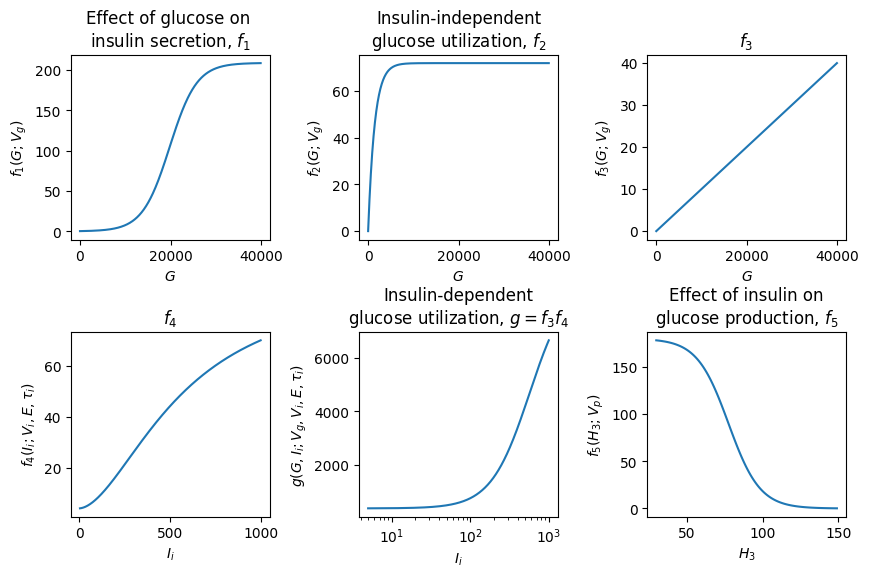

In [ ]:
f, axs = plt.subplots(2,3, figsize=(10,6))

plt.subplots_adjust(wspace=0.45, hspace=0.5)

Gs = np.arange(0, 40_000, 100)
Iis = np.arange(5, 1000, 1)
H3s = np.arange(30, 150, 1)

axs[0,0].plot(Gs, f1(Gs, params.V_g, 1))
axs[0,1].plot(Gs, f2(Gs, params.V_g))
axs[0,2].plot(Gs, _f3(Gs, params.V_g))
axs[1,0].plot(Iis, _f4(Iis, params.V_i, params.E, params.tau_i))
axs[1,1].plot(Iis, g(95000, Iis, params.V_g, params.V_i, params.E, params.tau_i))
axs[1,2].plot(H3s, f5(H3s, params.V_p))

axs[0,0].set_ylabel(r'$f_1(G; V_g)$')
axs[0,1].set_ylabel(r'$f_2(G; V_g)$')
axs[0,2].set_ylabel(r'$f_3(G; V_g)$')
axs[1,0].set_ylabel(r'$f_4(I_i; V_i, E, \tau_i)$')
axs[1,1].set_ylabel(r'$g(G, I_i; V_g, V_i, E, \tau_i)$')
axs[1,2].set_ylabel(r'$f_5(H_3; V_p)$')

for ax in axs[0, :]:
    ax.set_xlabel('$G$')
axs[1,0].set_xlabel('$I_i$')
axs[1,1].set_xlabel('$I_i$')
axs[1,2].set_xlabel('$H_3$')

axs[0,0].set_title('Effect of glucose on \ninsulin secretion, $f_1$')
axs[0,1].set_title('Insulin-independent\nglucose utilization, $f_2$')
axs[0,2].set_title('$f_3$')
axs[1,0].set_title('$f_4$')
axs[1,1].set_title('Insulin-dependent\nglucose utilization, $g=f_3 f_4$')
axs[1,2].set_title('Effect of insulin on\nglucose production, $f_5$')

# axs[1,0].set_xscale('log')
axs[1,1].set_xscale('log')

# Test simulation. Run the model to simulate plasma glucose and insulin when glucose is infused into blood with a constant rate F

In [ ]:
t_span = [0, 5500]

dt = 0.01 # sec

t_eval = np.arange(4500, t_span[1], dt)

state_initial = (100, 200, 10500, 100, 100, 100)

In [ ]:
solution_withfeedback = solve_ivp(model, t_span, state_initial, args=[params,], method='RK45', t_eval=t_eval)

# The units of the vectors in `solution` are mU and mg (see the model definition above).
# Therefore, divide them by the corresponding volumes of distribution to obtain the concentrations:

solution_withfeedback.y[0] = solution_withfeedback.y[0]*1e3/(params.V_p*1e3) # mU --> µU --> µU/ml
solution_withfeedback.y[1] = solution_withfeedback.y[1]*1e3/(params.V_i*1e3) # mU --> µU --> µU/ml
solution_withfeedback.y[2] = solution_withfeedback.y[2]/(params.V_g*10) # mg --> mg/dl

Text(0.5, 1.0, 'Continuous glucose injection at a constant rate of <function <lambda> at 0x7b3b6be814e0> mg/min')

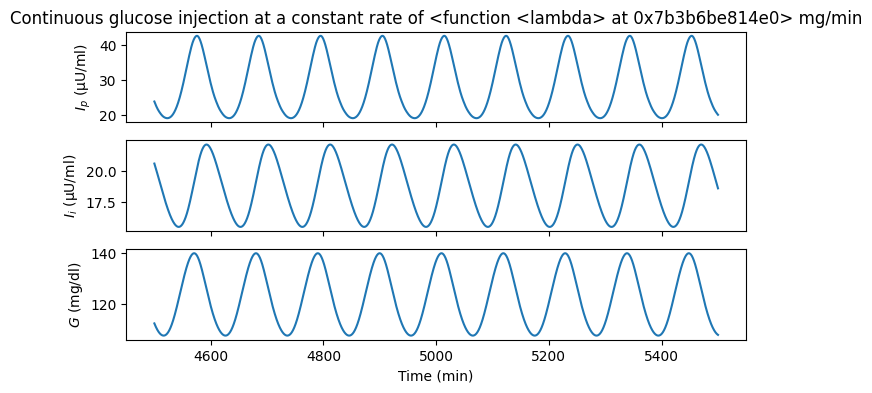

In [ ]:
f, axs = plt.subplots(3,1,figsize=(8, 4), sharex=True)

for ax, vec, var_name in zip(axs, solution_withfeedback.y, varnames):
    ax.plot(solution_withfeedback.t, vec, label=var_name)
ax.set_xlabel('Time (min)')
axs[0].set_ylabel('$I_p$ (µU/ml)')
axs[1].set_ylabel('$I_i$ (µU/ml)')
axs[2].set_ylabel('$G$ (mg/dl)')

axs[0].set_title(f'Continuous glucose injection at a constant rate of {params.F} mg/min')


# 1.2.1 Feedback functions, part (2) -- See above, "Plot functions f1, f2, etc."

# 1.2.2 Task 2. Constant glucose infusion

## Part "1" — How amplitude of oscillation of Glucose and Insulin depends on glucose infusion rate

In [ ]:
from scipy.signal import find_peaks

In [ ]:
Fs = np.arange(0, 301, 5)
amp_glc = []
amp_ins = []
solutions = []


for F_val in Fs:

    params.F = lambda t : F_val

    solution = solve_ivp(model, t_span, state_initial, args=[params,], method='RK45', t_eval=t_eval)

    insulin_in_plasma = solution.y[0]*1e3/(params.V_p*1e3) # mU --> µU --> µU/ml
    glucose_in_plasma = solution.y[2]/(params.V_g*10) # mg --> mg/dl

    solutions.append([insulin_in_plasma, glucose_in_plasma, solution.t])

    amp_ins.append(insulin_in_plasma.max() - insulin_in_plasma.min())
    amp_glc.append(glucose_in_plasma.max() - glucose_in_plasma.min())

    ## Check that maximum and minimum okay-estimates the peaks and valleys of the timeseries
#     mi = insulin_in_plasma.min()
#     ma = insulin_in_plasma.max()

#     plt.figure()
#     plt.plot(solution.t, insulin_in_plasma, color='k')
#     plt.axhline(mi, color='b', ls='--')
#     plt.axhline(ma, color='r', ls='--')

Text(0.5, 0, 'Rate of glucose infusion (mg/min)')

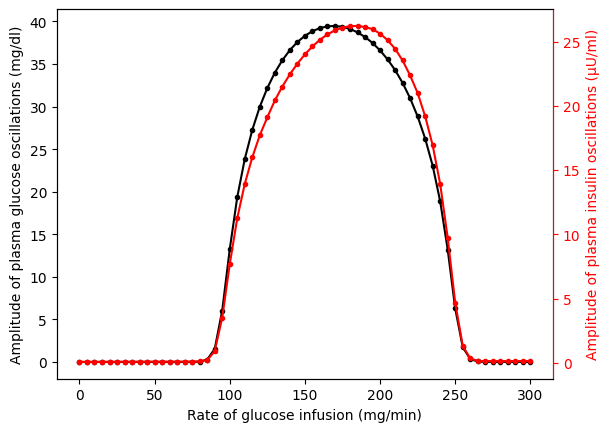

In [ ]:
f,ax = plt.subplots()
ax.plot(Fs, amp_glc, 'k.-')
ax.set_ylabel('Amplitude of plasma glucose oscillations (mg/dl)')

ax1= ax.twinx()

set_color = 'r'

ax1.plot(Fs, amp_ins, '.-', color=set_color)
ax1.set_ylabel('Amplitude of plasma insulin oscillations (µU/ml)', color=set_color)
ax1.tick_params(axis='y', colors=set_color)
ax1.spines['right'].set_color(set_color)

ax.set_xlabel('Rate of glucose infusion (mg/min)')

## 3D plot of Glucose-Insulin phase diagram at different values of F

### a. Matplotlib with widgets — fast with plotting, but hard to navigate in 3D (rotate, zoom the graph etc.)

Text(0.5, 0, '$G$ (mg/dl)')

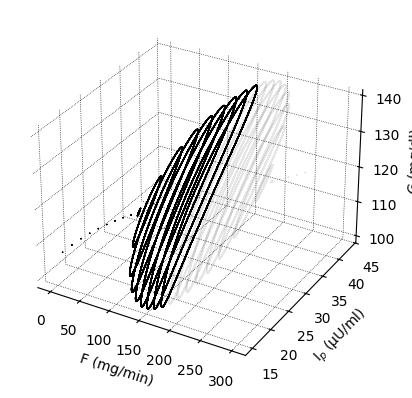

In [ ]:
# from mpl_toolkits.mplot3d import Axes3D # Not needed in google colab
# %matplotlib widget

fig = plt.figure()
ax = plt.axes(projection='3d')

nskip = 2
fmax = 180

for F, sol in zip(Fs[::nskip], solutions[::nskip]):
    t = sol[-1]
    fs = np.ones(t.size)*F
    plasma_glucose = sol[1]
    plasma_insulin = sol[0]
    if F < fmax:
        ax.plot3D(fs, plasma_insulin, plasma_glucose, color='k', alpha=1, lw=1)
    else:
        ax.plot3D(fs, plasma_insulin, plasma_glucose, color='k', alpha=0.1, lw=1)

# === Remove gray pane shading ===
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))  # Transparent
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

kw = dict(color='k', linewidth=0.5, linestyle=':')

ax.xaxis._axinfo['grid'].update(kw)
ax.yaxis._axinfo['grid'].update(kw)
ax.zaxis._axinfo['grid'].update(kw)

ax.set_xlabel('F (mg/min)')
ax.set_ylabel('I$_p$ (µU/ml)')
ax.set_zlabel('$G$ (mg/dl)')

#### b. Plotly — slow with plotting multiple lines, but easy to explore in 3D (rotate, zoom, etc.). If re-plot multiple times may crash the tab, so it needs to be restarted.

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

nskip = 2
fmax = 200

t_skip = 20

for F, sol in zip(Fs[::nskip], solutions[::nskip]):
    t = sol[-1]
    fs = np.ones(t.size)*F
    plasma_glucose = sol[1]
    plasma_insulin = sol[0]

    if F < fmax:
        fig.add_trace(go.Scatter3d(
            x=fs[::t_skip],
            y=plasma_insulin[::t_skip],
            z=plasma_glucose[::t_skip],
            mode='lines',
            line=dict(
                color=(0,0,0,1), # (R G B Alpha)
                width=4,
            ), showlegend=False
        ))


# Customize layout
fig.update_layout(
    scene=dict(
        xaxis_title='F (mg/min)',
        yaxis_title='I_p (µU/ml)',
        zaxis_title='G (mg/dl)',
        xaxis=dict(showline=True, linecolor='black'),
        yaxis=dict(showline=True, linecolor='black'),
        zaxis=dict(showline=True, linecolor='black'),
    ),
    title='Effect of F on oscillation',
    width=800,
    height=800
)

# Set the camera view
fig.update_layout(scene_camera=dict(
    eye=dict(x=1.35, y=-1.35, z=1.35)  # controls the camera position
))

Output hidden; open in https://colab.research.google.com to view.

## Part "2" — Blocking the feedback between Insulin and Glucose production in the liver (f5=0)

In [ ]:
params.f5_function = lambda H3, V_p : 0

In [ ]:
solution_nofeedback = solve_ivp(model, t_span, state_initial, args=[params,], method='RK45', t_eval=t_eval)

solution_nofeedback.y[0] = solution_nofeedback.y[0]*1e3/(params.V_p*1e3) # mU --> µU --> µU/ml
solution_nofeedback.y[1] = solution_nofeedback.y[1]*1e3/(params.V_i*1e3) # mU --> µU --> µU/ml
solution_nofeedback.y[2] = solution_nofeedback.y[2]/(params.V_g*10) # mg --> mg/dl

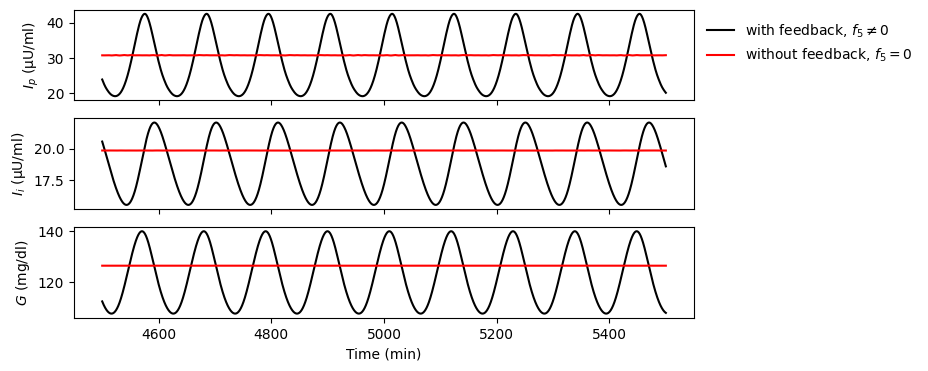

In [ ]:
f, axs = plt.subplots(3,1,figsize=(8, 4), sharex=True)

for ax, vec, vec_nofeedback, var_name in zip(axs, solution_withfeedback.y, solution_nofeedback.y, varnames):
    ax.plot(solution_withfeedback.t, vec, label=var_name, color='k')
    ax.plot(solution_withfeedback.t, vec_nofeedback, label=var_name, color='r')

ax.set_xlabel('Time (min)')
axs[0].set_ylabel('$I_p$ (µU/ml)')
axs[1].set_ylabel('$I_i$ (µU/ml)')
axs[2].set_ylabel('$G$ (mg/dl)')

axs[0].legend(handles=[plt.Line2D([0], [0], ls='-', label=r'with feedback, $f_5\neq 0$', color='k'),
                      plt.Line2D([0], [0], ls='-', label='without feedback, $f_5=0$', color='r')], bbox_to_anchor=(1,1), frameon=False)


# 1.2.3. Task 3: Pancreatic pacemaker

It is known that pancreatic beta cells release insulin regularly, with a period of about 5 minutes. Modify function f1 so that it oscillates.

In [ ]:
def f1_oscillating(G, V_g, t): return 209 / ( 1 + np.exp( -G / (300 * V_g) + 6.6 ) ) * (1 + np.sin(2*np.pi*t/13))

params.f1_function = f1_oscillating

params.f5_function = f5

params.F = lambda t : 216

In [ ]:
t_span = [0, 2000]

dt = 0.01 # sec

t_eval = np.arange(500, t_span[1], dt)

state_initial = (100, 200, 10500, 100, 100, 100)

In [ ]:
solution = solve_ivp(model, t_span, state_initial, args=[params,], method='RK45', t_eval=t_eval)

# The units of the vectors in `solution` are mU and mg (see the model definition above).
# Therefore, divide them by the corresponding volumes of distribution to obtain the concentrations:

solution.y[0] = solution.y[0]*1e3/(params.V_p*1e3) # mU --> µU --> µU/ml
solution.y[1] = solution.y[1]*1e3/(params.V_i*1e3) # mU --> µU --> µU/ml
solution.y[2] = solution.y[2]/(params.V_g*10) # mg --> mg/dl

Text(0.5, 1.0, 'Rapid oscillation of Insulin release (top) does not result in rapid oscillation of plasma Glucose (bottom)')

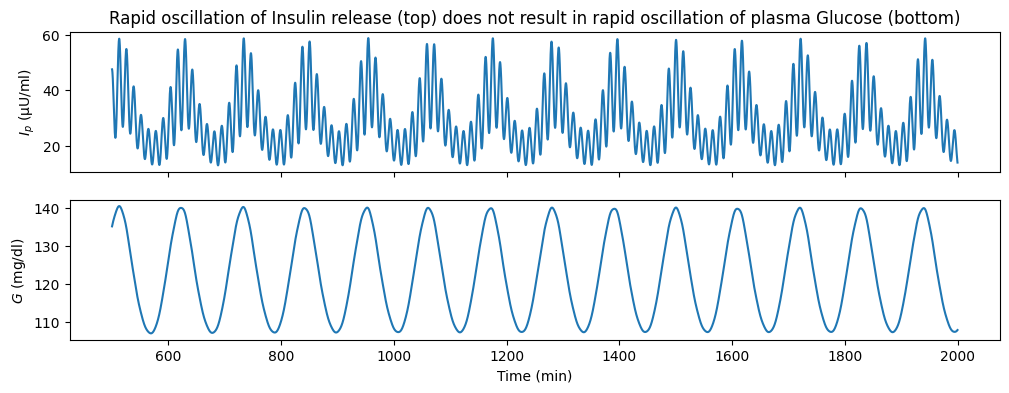

In [ ]:
f, (ax,ax1) = plt.subplots(2,1,figsize=(12, 4), sharex=True)


ax.plot(solution.t, solution.y[0])
ax1.plot(solution.t, solution.y[2])
ax1.set_xlabel('Time (min)')
ax.set_ylabel('$I_p$ (µU/ml)')
ax1.set_ylabel('$G$ (mg/dl)')

ax.set_title(f'Rapid oscillation of Insulin release (top) does not result in rapid oscillation of plasma Glucose (bottom)')


# 1.2.X Task X: Response of plasma glucose to a meal

We model a meal as F being 0 everywhere but a time interval, in which F is a constant > 0.

In [ ]:
def meals_F(t, meal_start_times, duration, F_max):
    meals_ends = meal_start_times + duration
    if np.any([(t>t1)*(t<t2) for t1, t2 in zip(meal_start_times, meals_ends)]):
        return F_max
    else:
        return 0

In [ ]:
t_span = [0, 2500]

dt = 0.01 # sec

t_eval = np.arange(500, t_span[1], dt)

state_initial = (100, 200, 10500, 100, 100, 100)

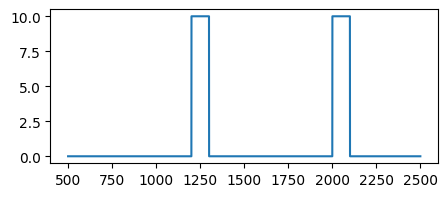

In [ ]:
plt.figure(figsize=(5,2))

plt.plot(t_eval, [meals_F(ti, np.array([1200, 2000]), 100, 10) for ti in t_eval])

In [ ]:
meal_duration = 30 # min
meal_times = np.array([750, 1200, 2000])
amp = 120
params.F = lambda t : meals_F(t, meal_times, meal_duration, amp)
params.f1_function = f1

solution = solve_ivp(model, t_span, state_initial, args=[params,], method='RK45', t_eval=t_eval)

# The units of the vectors in `solution` are mU and mg (see the model definition above).
# Therefore, divide them by the corresponding volumes of distribution to obtain the concentrations:

solution.y[0] = solution.y[0]*1e3/(params.V_p*1e3) # mU --> µU --> µU/ml
solution.y[1] = solution.y[1]*1e3/(params.V_i*1e3) # mU --> µU --> µU/ml
solution.y[2] = solution.y[2]/(params.V_g*10) # mg --> mg/dl

Text(0.5, 1.0, 'Three 30-min meals')

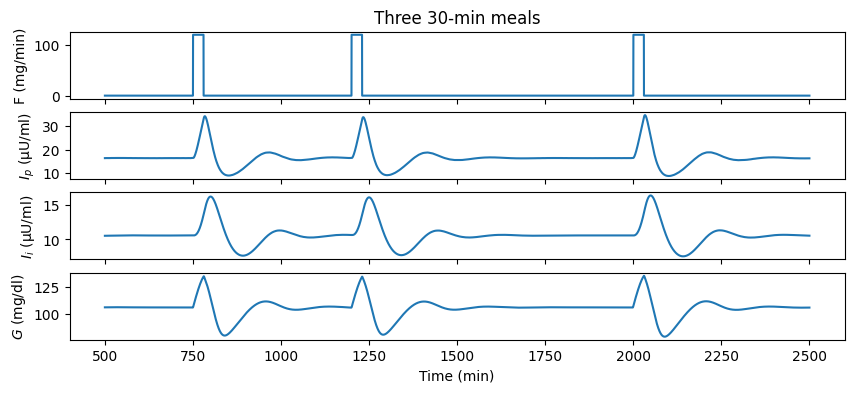

In [ ]:
f, axs = plt.subplots(4,1,figsize=(10, 4), sharex=True)

axs[0].plot(solution.t, [meals_F(ti, meal_times, meal_duration, amp) for ti in solution.t])
axs[0].set_ylabel('F (mg/min)')

for ax, vec, var_name in zip(axs[1:], solution.y, varnames):
    ax.plot(solution.t, vec, label=var_name)
ax.set_xlabel('Time (min)')
axs[1].set_ylabel('$I_p$ (µU/ml)')
axs[2].set_ylabel('$I_i$ (µU/ml)')
axs[3].set_ylabel('$G$ (mg/dl)')

axs[0].set_title(f'Three {meal_duration}-min meals')


(700.0, 1200.0)

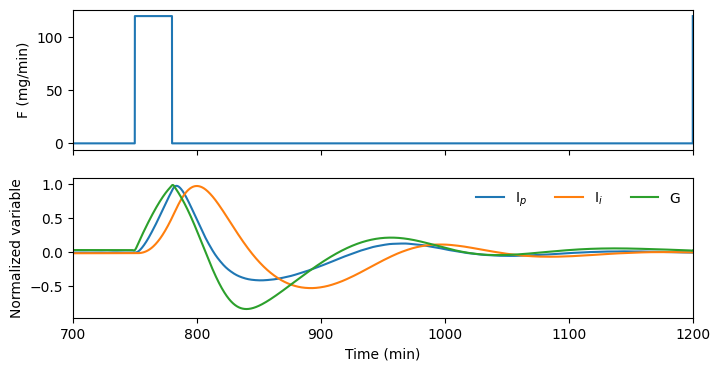

In [ ]:
normalize = lambda x : (x - x.mean())/(x.max()-x.mean())

f, (ax_meals,ax) = plt.subplots(2,1,figsize=(8, 4), sharex=True)

ax_meals.plot(solution.t, [meals_F(ti, meal_times, meal_duration, amp) for ti in solution.t])
ax_meals.set_ylabel('F (mg/min)')

for vec, var_name in zip(solution.y[:3], varnames):
    ax.plot(solution.t, normalize(vec), label=var_name)
ax.set_xlabel('Time (min)')
ax.legend(frameon=False, ncol=3)
ax.set_ylabel('Normalized variable')

ax.set_xlim(700, 1200)